**3. TIỀN XỬ LÝ DỮ LIỆU**

In [ ]:
#Khai báo thư viện cần dùng
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

In [ ]:
# đọc dữ liệu
df = pd.read_csv("Healthcare.csv")
# in ra kich thuoc du lieu
df.shape

(25000, 6)

In [ ]:
df.describe()

,Patient_ID,Age,Symptom_Count
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,45.302240,5.001440
std,7217.022701,26.106224,1.415796
min,1.000000,1.000000,3.000000
25%,6250.750000,23.000000,4.000000
50%,12500.500000,45.000000,5.000000
75%,18750.250000,68.000000,6.000000
max,25000.000000,90.000000,7.000000


from matplotlib import pyplot as plt
_df_0['Patient_ID'].plot(kind='hist', bins=20, title='Patient_ID')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Age'].plot(kind='hist', bins=20, title='Age')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['Symptom_Count'].plot(kind='hist', bins=20, title='Symptom_Count')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3.plot(kind='scatter', x='Patient_ID', y='Age', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_4.plot(kind='scatter', x='Age', y='Symptom_Count', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_5['Patient_ID'].plot(kind='line', figsize=(8, 4), title='Patient_ID')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['Age'].plot(kind='line', figsize=(8, 4), title='Age')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_7['Symptom_Count'].plot(kind='line', figsize=(8, 4), title='Symptom_Count')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Patient_ID     25000 non-null  int64 
 1   Age            25000 non-null  int64 
 2   Gender         25000 non-null  object
 3   Symptoms       25000 non-null  object
 4   Symptom_Count  25000 non-null  int64 
 5   Disease        25000 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.1+ MB


***3.1. Làm sạch dữ liệu***

In [ ]:
# kiểm tra dữ liệu bị khuyết
df.isna()

,Patient_ID,Age,Gender,Symptoms,Symptom_Count,Disease
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
24995,False,False,False,False,False,False
24996,False,False,False,False,False,False
24997,False,False,False,False,False,False
24998,False,False,False,False,False,False


In [ ]:
df.isna().sum()

,0
Patient_ID,0
Age,0
Gender,0
Symptoms,0
Symptom_Count,0
Disease,0


In [ ]:
# Kiểm tra trùng lặp
df.duplicated().sum()

np.int64(0)

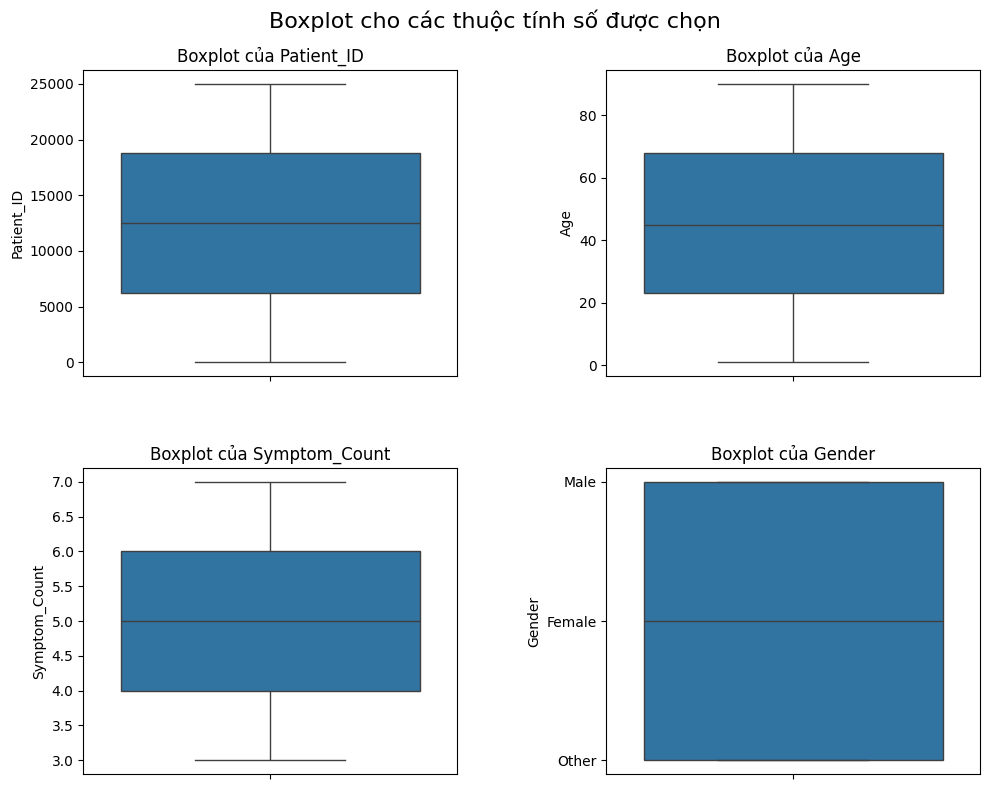

In [ ]:
#Kiểm tra dữ liệu outliners bằng cách vẽ boxplot cho từng thuộc tính
#Vẽ boxplot của 4 cột số
import matplotlib.pyplot as plt # Import matplotlib

# Chọn 4 cột số để vẽ boxplot
selected_numerical_cols = ['Patient_ID', 'Age', 'Symptom_Count', 'Gender']

fig, axes = plt.subplots(2, 2, figsize=(10, 8)) # 2 hàng, 2 cột cho 4 boxplot
axes = axes.flatten()

#Tiêu đề cho mô hình
fig.suptitle("Boxplot cho các thuộc tính số được chọn", fontsize=16)

for index, col in enumerate(selected_numerical_cols):
    #Hiển thị tiêu đề cho từng ô con
    axes[index].set_title("Boxplot của {}".format(col))
    #ve boxplot cho từng ô con
    sns.boxplot(y=df[col], ax=axes[index])

plt.tight_layout()
#Tạo khoảng cách giữa các ô con
plt.subplots_adjust(hspace=0.3, wspace=0.4)
plt.show()

**3.2. Chuẩn hóa/biến đổi dữ liệu và  Rút gọn dữ liệu**



In [ ]:
df = df.drop('Patient_ID',axis=1)

In [ ]:
# các giá trị ở Symptoms
df['Symptoms'].unique()

array(['fever, back pain, shortness of breath',
       'insomnia, back pain, weight loss',
       'sore throat, vomiting, diarrhea', ..., 'anxiety, nausea, tremors',
       'muscle pain, rash, diarrhea, joint pain',
       'sweating, abdominal pain, fever, insomnia, blurred vision, anxiety, back pain'],
      dtype=object)

In [ ]:
df['Disease'].unique()

array(['Allergy', 'Thyroid Disorder', 'Influenza', 'Stroke',
       'Heart Disease', 'Food Poisoning', 'Bronchitis', 'COVID-19',
       'Dermatitis', 'Diabetes', 'Arthritis', 'Sinusitis', 'Dementia',
       "Parkinson's", 'Obesity', 'Asthma', 'Depression', 'Gastritis',
       'Liver Disease', 'Epilepsy', 'IBS', 'Tuberculosis', 'Pneumonia',
       'Anemia', 'Migraine', 'Common Cold', 'Anxiety',
       'Chronic Kidney Disease', 'Ulcer', 'Hypertension'], dtype=object)

One-Hot Encoding: tách thuộc tính thành các cột 0/1 để tránh thứ tự giả.

In [ ]:
# 1. Tách chuỗi triệu chứng thành danh sách các triệu chứng
df["Symptoms_list"] = df["Symptoms"].str.split(",").apply(lambda x: [i.strip() for i in x])

# 2. "Phát nổ" (explode) DataFrame để mỗi triệu chứng trở thành một hàng riêng biệt
df_exploded = df.explode("Symptoms_list")

# 3. Áp dụng One-Hot Encoding cho các triệu chứng đã được "phát nổ"
dummy = pd.get_dummies(df_exploded["Symptoms_list"])

# 4. Gom nhóm lại theo chỉ mục gốc (sử dụng max để lấy 0/1)
dummy_grouped = dummy.groupby(level=0).max()

# 5. Chuyển đổi sang kiểu số nguyên
dummy_grouped = dummy_grouped.astype(int)
# Final DF loại bỏ 2 cột "Symptoms" & without "Symptoms_list"
df = pd.concat([df.drop(columns=["Symptoms", "Symptoms_list"]), dummy_grouped], axis=1)

In [ ]:
df['Gender'] = df['Gender'].apply(lambda x:1 if x == 'Male' else 0)

Label Encoding: biến mỗi nhãn thành số nguyên.


In [ ]:
disease_to_superclass = {
    # 1) Respiratory & Infections
    "COVID-19": "Respiratory/Infectious",
    "Asthma": "Respiratory/Infectious",
    "Bronchitis": "Respiratory/Infectious",
    "Pneumonia": "Respiratory/Infectious",
    "Tuberculosis": "Respiratory/Infectious",
    "Common Cold": "Respiratory/Infectious",
    "Sinusitis": "Respiratory/Infectious",
    "Influenza": "Respiratory/Infectious",

    # 2) Cardio-metabolic & Blood
    "Heart Disease": "Cardio-metabolic/Blood",
    "Hypertension": "Cardio-metabolic/Blood",
    "Diabetes": "Cardio-metabolic/Blood",
    "Thyroid Disorder": "Cardio-metabolic/Blood",
    "Obesity": "Cardio-metabolic/Blood",
    "Anemia": "Cardio-metabolic/Blood",

    # 3) Digestive & Liver
    "Gastritis": "Digestive/Liver",
    "IBS": "Digestive/Liver",
    "Ulcer": "Digestive/Liver",
    "Food Poisoning": "Digestive/Liver",
    "Liver Disease": "Digestive/Liver",

    # 4) Neurological & Stroke
    "Epilepsy": "Neuro/Stroke",
    "Migraine": "Neuro/Stroke",
    "Dementia": "Neuro/Stroke",
    "Parkinson's": "Neuro/Stroke",
    "Stroke": "Neuro/Stroke",

    # 5) Mental Health
    "Depression": "Mental Health",
    "Anxiety": "Mental Health",

    # 6) Immune / Allergy / Skin
    "Allergy": "Immune/Allergy/Skin",
    "Dermatitis": "Immune/Allergy/Skin",

    # 7) Other Chronic (Kidney, Joint)
    "Chronic Kidney Disease": "Other Chronic",
    "Arthritis": "Other Chronic",
}

In [ ]:
df['Superclass'] = df['Disease'].map(disease_to_superclass)

In [ ]:
df['Disease'].value_counts()

,count
Disease,
Anxiety,911
Arthritis,896
Food Poisoning,871
Depression,859
Allergy,858
Bronchitis,856
Dermatitis,856
Thyroid Disorder,855
Migraine,854


In [ ]:
df['Superclass'].value_counts()

,count
Superclass,
Respiratory/Infectious,6545
Cardio-metabolic/Blood,4975
Digestive/Liver,4168
Neuro/Stroke,4125
Mental Health,1770
Immune/Allergy/Skin,1714
Other Chronic,1703


In [ ]:
# mã hóa cột Country với Label encoder sử dụng scikit learn encoder = LabelEncoder()
le_disease = LabelEncoder()
df["Disease"] = le_disease.fit_transform(df["Disease"])

print("Disease classes (27 labels):")
print(le_disease.classes_)


le_super = LabelEncoder()
df["Superclass"] = le_super.fit_transform(df["Superclass"])

print("\nSuperclass classes (7 labels):")
print(le_super.classes_)

Disease classes (27 labels):
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

Superclass classes (7 labels):
[0 1 2 3 4 5 6]


In [ ]:
df


,Age,Gender,Symptom_Count,Disease,abdominal pain,anxiety,appetite loss,back pain,blurred vision,chest pain,...,shortness of breath,sneezing,sore throat,sweating,swelling,tremors,vomiting,weight gain,weight loss,Superclass
0,29,1,3,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
1,76,0,3,27,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
2,78,1,3,19,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,58,0,4,26,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
4,55,0,3,16,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,42,1,6,29,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
24996,36,1,6,8,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
24997,70,0,3,2,0,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
24998,9,0,4,22,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**3.4 Chia dữ liệu thành tập huấn luyện và tập kiểm tra (train/test).**

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os # Import os for os.path.join

# Tải lại dữ liệu gốc để lấy văn bản 'Symptoms', vì nó đã bị loại bỏ khỏi 'df'
original_data = pd.read_csv('Healthcare.csv')

# Mục tiêu đã được mã hóa nhãn dưới dạng số nguyên trong df["Superclass"]
y = df["Superclass"]
# y_enc chính là y, vì nó đã được mã hóa
y_enc = y


X = pd.DataFrame()
X["Symptoms"] = original_data["Symptoms"]
X["Age"] = df["Age"]
X["Gender"] = df["Gender"]
X["Symptom_Count"] = df["Symptom_Count"]

# Chuyển đổi cột 'Gender' sang dạng số trong X
X['Gender'] = X['Gender'].apply(lambda x: 1 if x == 'Male' else (0 if x == 'Female' else 0)) # Assuming 'Other' also maps to 0

# Chia tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc
)

# Tải bộ mã hóa BERT/MiniLM
bert_model = SentenceTransformer("all-MiniLM-L6-v2")

# Mã hóa văn bản triệu chứng → nhúng dày đặc
train_symptoms = X_train["Symptoms"].astype(str).tolist()
test_symptoms  = X_test["Symptoms"].astype(str).tolist()

emb_train = bert_model.encode(train_symptoms, batch_size=64, show_progress_bar=True)
emb_test  = bert_model.encode(test_symptoms, batch_size=64, show_progress_bar=True)

print("Kích thước nhúng:", emb_train.shape)

# Các đặc trưng số: Age, Gender, Symptom_Count
num_cols = ["Age", "Gender", "Symptom_Count"]

scaler = StandardScaler()
num_train = scaler.fit_transform(X_train[num_cols])
num_test  = scaler.transform(X_test[num_cols])

# Nối [nhúng BERT | các đặc trưng số]
X_train_bert = np.hstack([emb_train, num_train])
X_test_bert  = np.hstack([emb_test, num_test])

print("Kích thước tập huấn luyện cuối cùng:", X_train_bert.shape)
print("Kích thước tập kiểm tra cuối cùng:", X_test_bert.shape)

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Kích thước nhúng: (20000, 384)
Kích thước tập huấn luyện cuối cùng: (20000, 387)
Kích thước tập kiểm tra cuối cùng: (5000, 387)


In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report

cat = CatBoostClassifier(
    iterations=800,
    depth=8,
    learning_rate=0.03,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

cat.fit(X_train_bert, y_train)

# Dự đoán
y_pred = cat.predict(X_test_bert).flatten()

In [ ]:
# Dự đoán
y_pred = cat.predict(X_test_bert).flatten()

# Tạo lại LabelEncoder cho các siêu lớp để đảm bảo tên mục tiêu chính xác
# Điều này là cần thiết vì 'le_super' có thể đã bị mất hoặc được tái huấn luyện trên dữ liệu số
# Chúng ta lấy trực tiếp các tên chuỗi duy nhất từ các giá trị của từ điển 'disease_to_superclass'
all_superclass_names = list(set(disease_to_superclass.values()))
# Tạo một LabelEncoder tạm thời và huấn luyện nó trên các tên chuỗi này
temp_le_super = LabelEncoder()
temp_le_super.fit(all_superclass_names)

print("=========== Báo cáo phân loại BERT + CatBoost (7 Siêu danh mục) ===========\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=temp_le_super.classes_   # Sử dụng các lớp từ LabelEncoder được tạo lại
))